In [63]:
import uproot
import pandas as pd
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Read NuSyst Tree ROOT file

In [64]:
with uproot.open("NuSystTree_Updated.root") as f:

    # Note that this time we are using awkward array
    df_event = f["events"].arrays(library="ak")

    df_meta = f["tweak_metadata"].arrays(library="pd")

In [65]:
df_meta

,fUniqueID,fBits,fString,ntweaks,tweakvalues
0,0,50331648,DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA,3,[-1.0 0.0 1.0]
1,0,50331648,DUNEDAS2026ExampleReweighter_NuSystTutorial_DialB,3,[-1.0 0.0 1.0]


In [66]:
DialColumnName_prefix = "DUNEDAS2026ExampleReweighter_NuSystTutorial"

DialARWColName = f"tweak_responses_{DialColumnName_prefix}_DialA"

df_event[DialARWColName].show(5)

[[0.868, 1, 1.13],
 [-7.99, 1, 9.99],
 [-3.92, 1, 5.92],
 ...,
 [-0.353, 1, 2.35]]


We want to take the "+1 sigma" reweight and apply it to the simulation.
From the metadata, we know that the third (index=2) of each reweight array corresponds to +1 sigma.
This can be done by using python slicing.

In [67]:
# [:,2]
# - ":" means we are selecting all elements from the "row" (or the first dimension/axis)
# - "2" means we are only selecting the third (index=2) element from the "column" (or the second dimension/axis) 
arr_DialA_pOneSig = df_event[DialARWColName][:,2]
arr_DialA_pOneSig.show(5)

[1.13,
 9.99,
 5.92,
 ...,
 2.35]


# Now let's draw Q2 distributions
- h: CV
- h_RW: Reweighted using arr_DialA_pOneSig

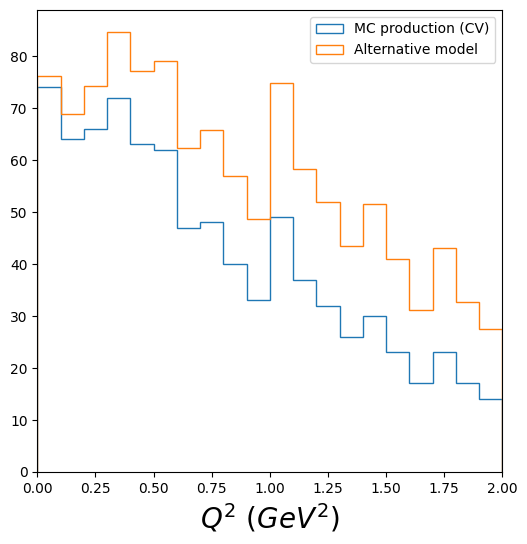

In [70]:
fig, ax = plt.subplots(figsize=(6,6))

Binning = np.linspace(0, 2.0, 20+1)

h = np.histogram(
    df_event['Q2'],
    bins=Binning
)[0]
ax.hist(
    Binning[:-1],
    bins=Binning,
    weights=h,
    histtype='step',
    label='MC production (CV)'
)
ax.set_xlim(Binning[0], Binning[-1])
ax.set_xlabel(r'$Q^{2}$ $(GeV^{2})$', fontsize=20)

h_RW = np.histogram(
    df_event['Q2'],
    bins=Binning,
    weights=arr_DialA_pOneSig
)[0]
ax.hist(
    Binning[:-1],
    bins=Binning,
    weights=h_RW,
    histtype='step',
    label='Alternative model'
)

ax.legend(loc='upper right', fontsize=10)


# Ratio of the two hisograms

Text(0.5, 0, '$Q^{2}$ $(GeV^{2})$')

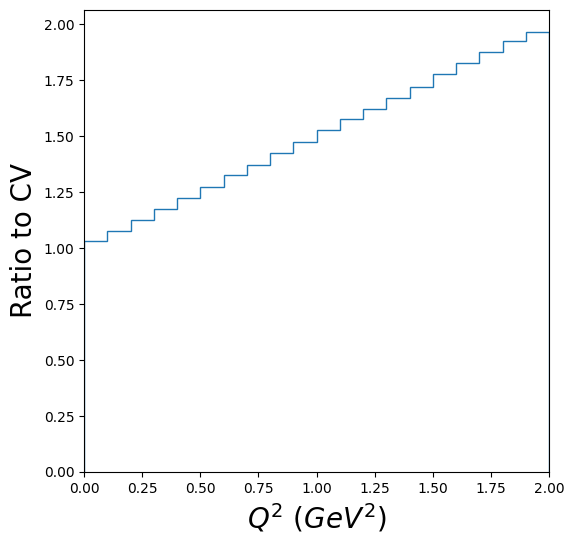

In [69]:
fig, ax = plt.subplots(figsize=(6,6))

h_ratio = h_RW/h

ax.hist(
    Binning[:-1],
    bins=Binning,
    weights=h_ratio,
    histtype='step',
    label='MC production (CV)'
)
ax.set_ylabel('Ratio to CV', fontsize=20)
ax.set_xlim(Binning[0], Binning[-1])
ax.set_xlabel(r'$Q^{2}$ $(GeV^{2})$', fontsize=20)
